# How Noisy Timing Affects a Quantum "Coin Flip"

**Plain-language version, for the oral exam**

A quantum computer does calculations by applying short pulses of energy to
particles called qubits. One of the simplest pulses is a **gate**: a
precisely-timed nudge that flips the qubit from one state to another, a bit
like flipping a coin from heads to tails.

The nudge is controlled by a dial — the **frequency**, written $\omega$ — and
the flip only comes out perfectly if that dial stays exactly where it's set
for the whole pulse. In a real machine the dial wobbles slightly instead of
staying still. This notebook builds a small simulation that asks: **if the
dial wobbles randomly, how much does that ruin the flip, and does using a
*faster* pulse help you outrun the wobble?**

This is the same model and the same numbers as the full report — the code
here is rewritten with plainer names and more comments, and each section
starts with a short "what this section does and why" note, so I can talk
through every step in the oral exam without leaning on jargon.


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 110,
})

# One fixed "starting number" for the random number generator. Using the
# same starting number every time means re-running this notebook always
# reproduces exactly the same random wobbles, and therefore the same
# numbers and plots -- important so results can be checked/reproduced.
MASTER_SEED = 20260731


In [2]:
def qubit_equations(t, state, time_grid, wobble_values, dial_setting, wobble_size):
    '''The right-hand side of the four-number ODE system above, i.e. the
    rule 'given the current state, what is its rate of change right now'.
    solve_ivp calls this many times per run, at times that don't line up
    exactly with our wobble grid, so we rebuild omega(t) at time t by
    straight-line (linear) interpolation between the nearest grid points.
    '''
    u1, v1, u2, v2 = state
    wobble_now = np.interp(t, time_grid, wobble_values)
    omega_t = dial_setting + wobble_size * wobble_now
    return [omega_t * v2, -omega_t * u2, omega_t * v1, -omega_t * u1]


# Solver settings, fixed for every run in this notebook. Chosen so that a
# no-wobble run matches the exact pen-and-paper answer to about one part in
# ten billion, while still being fast enough to afford thousands of runs.
SOLVER_SETTINGS = dict(rtol=1e-6, atol=1e-9)
MAX_STEP_FRACTION = 1.0 / 50.0  # solver never takes a step bigger than T/50


def generate_wobble(gate_time, num_steps, rng):
    '''Build one random 'wobble path' W(t): a random walk made of
    num_steps independent random nudges, each nudge drawn from a normal
    (bell-curve) distribution. This is the standard recipe for simulating
    Brownian motion / a Wiener process on a computer.
    '''
    dt = gate_time / num_steps
    nudges = rng.normal(loc=0.0, scale=np.sqrt(dt), size=num_steps)
    wobble_values = np.concatenate(([0.0], np.cumsum(nudges)))
    time_grid = np.linspace(0.0, gate_time, num_steps + 1)
    return time_grid, wobble_values


def run_one_gate(dial_setting, wobble_size, gate_time, num_steps, rng,
                  start_state=(1.0, 0.0, 0.0, 0.0), keep_full_path=False):
    '''Simulate ONE attempt at the gate, from start to finish, with one
    randomly generated wobble path. Every single trajectory anywhere in
    this notebook is produced by a call to this one function -- it is the
    'engine'. `keep_full_path=True` also keeps a continuous solution we can
    evaluate at any time (used only for the illustration plot in Section 2)
    -- it costs a bit of extra time, so it's switched off by default.
    '''
    time_grid, wobble_values = generate_wobble(gate_time, num_steps, rng)
    solution = solve_ivp(
        qubit_equations,
        t_span=(0.0, gate_time),
        y0=list(start_state),
        method="RK45",  # a standard adaptive step-size Runge-Kutta solver
        args=(time_grid, wobble_values, dial_setting, wobble_size),
        max_step=gate_time * MAX_STEP_FRACTION,
        dense_output=keep_full_path,
        **SOLVER_SETTINGS,
    )
    return solution


### Checking the engine before trusting it

Before using this code for anything noisy, we switch the wobble off
completely (`wobble_size = 0`) and check the computer's answer against the
exact pen-and-paper answer. If they don't match closely, nothing built on
top of the engine can be trusted either.


In [3]:
def state_to_ab(state_vector):
    '''Turn the four real numbers back into the two complex amplitudes
    a and b that physicists actually think in terms of.'''
    u1, v1, u2, v2 = state_vector
    return u1 + 1j * v1, u2 + 1j * v2


dial_nominal = 1.0                       # omega_0: the "normal-speed" dial setting
T_nominal = np.pi / (2 * dial_nominal)   # gate time that gives a full flip at that speed

rng_check = np.random.default_rng(0)
no_wobble_run = run_one_gate(dial_nominal, 0.0, T_nominal, 300, rng_check)
a_end, b_end = state_to_ab(no_wobble_run.y[:, -1])

print("No-wobble result:  a =", a_end, " b =", b_end)
print("Expected exactly:  a = 0, b = -i")
print("How close we got (should be ~1):", abs(b_end) ** 2)


No-wobble result:  a = (-7.051512151967643e-13+0j)  b = -0.9999999999869084j
Expected exactly:  a = 0, b = -i
How close we got (should be ~1): 0.9999999999738167


**What to say about this check in the exam:** the simulated result lands
within about $10^{-9}$ of the exact answer, which is far smaller than any
effect we're about to study, so any fidelity loss we see later is genuinely
caused by the wobble, not by numerical sloppiness in the solver.


## 2. Picture: one clean run vs. one wobbly run

**What this section does:** shows, for a single example run, what the
wobble actually does to the qubit's state over time — a sanity-check picture
before we start counting failures over thousands of runs.


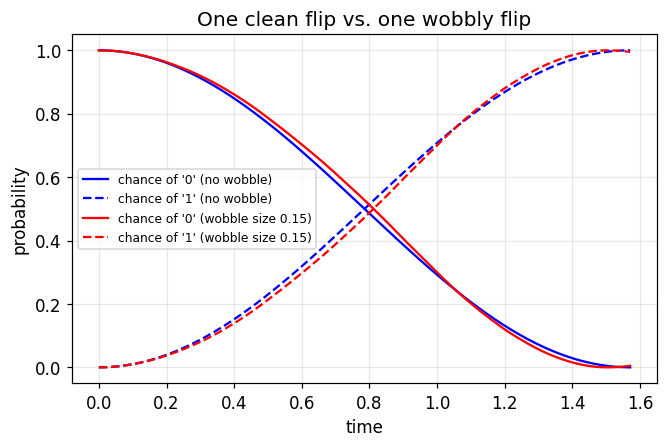

In [4]:
rng_picture = np.random.default_rng(1)
clean_run = run_one_gate(dial_nominal, 0.0, T_nominal, 300, rng_picture, keep_full_path=True)
wobbly_run = run_one_gate(dial_nominal, 0.15, T_nominal, 300, rng_picture, keep_full_path=True)

t_axis = np.linspace(0, T_nominal, 400)
clean_states = clean_run.sol(t_axis)
wobbly_states = wobbly_run.sol(t_axis)

pop_0_clean = clean_states[0] ** 2 + clean_states[1] ** 2   # |a|^2: chance of still being "0"
pop_1_clean = clean_states[2] ** 2 + clean_states[3] ** 2   # |b|^2: chance of being "1"
pop_0_wobbly = wobbly_states[0] ** 2 + wobbly_states[1] ** 2
pop_1_wobbly = wobbly_states[2] ** 2 + wobbly_states[3] ** 2

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(t_axis, pop_0_clean, "b-", label="chance of '0' (no wobble)")
ax.plot(t_axis, pop_1_clean, "b--", label="chance of '1' (no wobble)")
ax.plot(t_axis, pop_0_wobbly, "r-", label="chance of '0' (wobble size 0.15)")
ax.plot(t_axis, pop_1_wobbly, "r--", label="chance of '1' (wobble size 0.15)")
ax.set_xlabel("time")
ax.set_ylabel("probability")
ax.set_title("One clean flip vs. one wobbly flip")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


On a clean run the qubit ends up completely in state "1". On the wobbly
run it very nearly gets there, but is left with a small (roughly 5%) chance
of still being in state "0" — the flip is *almost* complete but not quite.
That leftover chance of being in the wrong state is exactly what "fidelity"
below is designed to measure.


## 3. Fidelity, and the "run it 1000 times" idea

**What this section does:** defines the one number, **fidelity**, that
measures how good a single flip was, and explains why we can't judge the
gate from just one run.

A single wobble path is random, so a single run tells us almost nothing
about how the gate performs *in general* — one run might get lucky, another
unlucky. So instead of trusting one run, we repeat the whole experiment
$N = 1000$ times with a fresh random wobble path each time, and look at the
**spread of outcomes**, not just one outcome. This "repeat many times and
look at the statistics" approach is a **Monte Carlo** experiment — like a
crash-test lab running the same collision a thousand times with slightly
different conditions each time, rather than trusting a single crash.

For each run we compute the **fidelity** $F$: a number between 0 and 1 that
says how close the qubit's final state is to the perfect target state
(1 = perfect flip, 0 = complete failure). Concretely, $F$ is the squared
overlap between the qubit's actual final state and the ideal state.


In [5]:
def fidelity(final_state, ideal_state):
    '''How close is `final_state` to `ideal_state`? Returns a number
    between 0 (nothing alike) and 1 (identical).'''
    a_f, b_f = state_to_ab(final_state)
    a_i, b_i = state_to_ab(ideal_state)
    overlap = np.conj(a_i) * a_f + np.conj(b_i) * b_f
    return float(np.abs(overlap) ** 2)


def ideal_state_for(dial_setting, gate_time):
    '''The perfect (no-wobble) end state, computed with the same engine
    (wobble size forced to zero) so it's always self-consistent.'''
    rng_dummy = np.random.default_rng(0)  # unused when wobble_size = 0
    result = run_one_gate(dial_setting, 0.0, gate_time, 4, rng_dummy)
    return result.y[:, -1]


def run_many_gates(dial_setting, wobble_size, gate_time, num_steps, num_runs, rng):
    '''The 'crash test': repeat the gate num_runs times at a fixed
    (dial_setting, wobble_size) and return every resulting fidelity.'''
    target = ideal_state_for(dial_setting, gate_time)
    fidelities = np.empty(num_runs)
    for k in range(num_runs):
        result = run_one_gate(dial_setting, wobble_size, gate_time, num_steps, rng)
        fidelities[k] = fidelity(result.y[:, -1], target)
    return fidelities


NUM_WOBBLE_STEPS = 300  # how finely the random path is drawn (checked for accuracy in Section 6)
NUM_RUNS = 1000          # how many repeats make up one "crash test" batch


## 4. How much wobble can the gate tolerate?

**What this section does:** sweeps the wobble size $\sigma$ from 0 (no
wobble) up to a fairly large value, running a full 1000-repeat crash test at
each value, and tracks how the *average* fidelity falls off. We also record
the point where average fidelity drops below 99% — a common target quality
level for quantum computing — and call that the **critical wobble size**,
$\sigma_c$.

**Runtime note:** each point on this sweep is 1000 individual simulations,
so the full sweep below runs 16,000 simulations and takes a few minutes.


In [6]:
def sweep_wobble_size(dial_setting, sigma_values, gate_time, num_steps, num_runs, rng):
    '''Repeat the crash test at every wobble size in sigma_values.
    Returns the average fidelity and its spread (standard deviation) at
    each value, plus every individual fidelity (kept for the histograms
    in Section 5, so we don't have to re-simulate).'''
    mean_fid = np.empty(len(sigma_values))
    spread_fid = np.empty(len(sigma_values))
    every_fid = np.empty((len(sigma_values), num_runs))
    for i, sigma in enumerate(sigma_values):
        fids = run_many_gates(dial_setting, sigma, gate_time, num_steps, num_runs, rng)
        mean_fid[i] = fids.mean()
        spread_fid[i] = fids.std()
        every_fid[i, :] = fids
    return mean_fid, spread_fid, every_fid


def find_critical_sigma(sigma_values, mean_fid, threshold=0.99):
    '''Find (by straight-line interpolation) the wobble size at which
    average fidelity first drops below `threshold`.'''
    sigma_values = np.asarray(sigma_values)
    mean_fid = np.asarray(mean_fid)
    below = np.where(mean_fid < threshold)[0]
    if len(below) == 0:
        return None
    i = below[0]
    if i == 0:
        return sigma_values[0]
    s0, s1 = sigma_values[i - 1], sigma_values[i]
    f0, f1 = mean_fid[i - 1], mean_fid[i]
    return s0 + (threshold - f0) * (s1 - s0) / (f1 - f0)


sigma_values = np.linspace(0.0, 0.30, 16)
rng_main_sweep = np.random.default_rng(MASTER_SEED + 1)
mean_fid_nominal, spread_fid_nominal, every_fid_nominal = sweep_wobble_size(
    dial_nominal, sigma_values, T_nominal, NUM_WOBBLE_STEPS, NUM_RUNS, rng_main_sweep
)
sigma_c_nominal = find_critical_sigma(sigma_values, mean_fid_nominal)
print(f"Critical wobble size at normal speed: sigma_c = {sigma_c_nominal:.4f}")


Critical wobble size at normal speed: sigma_c = 0.0863


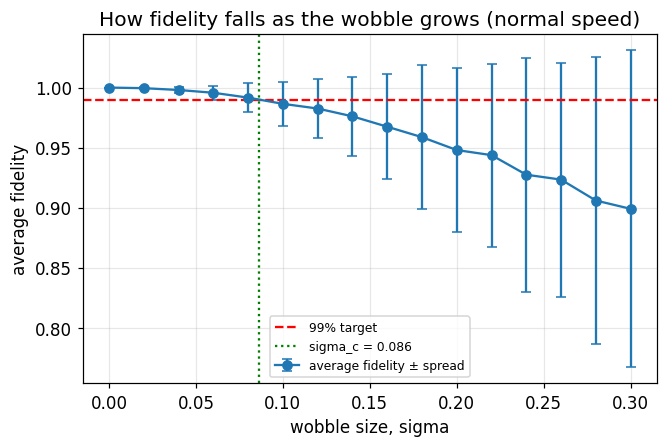

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.errorbar(sigma_values, mean_fid_nominal, yerr=spread_fid_nominal,
            fmt="o-", capsize=3, color="tab:blue", label="average fidelity ± spread")
ax.axhline(0.99, color="red", ls="--", label="99% target")
ax.axvline(sigma_c_nominal, color="green", ls=":", label=f"sigma_c = {sigma_c_nominal:.3f}")
ax.set_xlabel("wobble size, sigma")
ax.set_ylabel("average fidelity")
ax.set_title("How fidelity falls as the wobble grows (normal speed)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


**Reading this plot:** fidelity falls off smoothly, not suddenly. It
crosses the 99% line at about $\sigma_c \approx 0.086$. Below roughly
$\sigma=0.05$ the spread (error bars) is tiny — every run is very similar —
but the spread grows a lot beyond that, which is a hint that the *average*
number alone is starting to hide something interesting (picked up again in
Section 5).


## 5. Does a faster pulse outrun the wobble?

**What this section does:** repeats the exact same sweep at two more pulse
speeds — a slow one and a fast one — to see whether pulse speed changes how
much wobble the gate can tolerate.

A "faster" pulse means a bigger dial setting $\omega_0$, which by
$T = \pi/(2\omega_0)$ means a *shorter* pulse — the flip happens quicker, so
there's less *time* for the wobble to build up and throw things off.


In [8]:
rng_slow = np.random.default_rng(MASTER_SEED + 2)
rng_fast = np.random.default_rng(MASTER_SEED + 3)

dial_slow, dial_fast = 0.5, 2.0
T_slow = np.pi / (2 * dial_slow)
T_fast = np.pi / (2 * dial_fast)

mean_fid_slow, _, _ = sweep_wobble_size(dial_slow, sigma_values, T_slow, NUM_WOBBLE_STEPS, NUM_RUNS, rng_slow)
mean_fid_fast, _, _ = sweep_wobble_size(dial_fast, sigma_values, T_fast, NUM_WOBBLE_STEPS, NUM_RUNS, rng_fast)

sigma_c_slow = find_critical_sigma(sigma_values, mean_fid_slow)
sigma_c_fast = find_critical_sigma(sigma_values, mean_fid_fast)

print(f"Slow pulse   (omega0=0.5, T={T_slow:.3f}): sigma_c = {sigma_c_slow:.4f}")
print(f"Normal pulse (omega0=1.0, T={T_nominal:.3f}): sigma_c = {sigma_c_nominal:.4f}")
print(f"Fast pulse   (omega0=2.0, T={T_fast:.3f}): sigma_c = {sigma_c_fast:.4f}")


Slow pulse   (omega0=0.5, T=3.142): sigma_c = 0.0295
Normal pulse (omega0=1.0, T=1.571): sigma_c = 0.0863
Fast pulse   (omega0=2.0, T=0.785): sigma_c = 0.2568


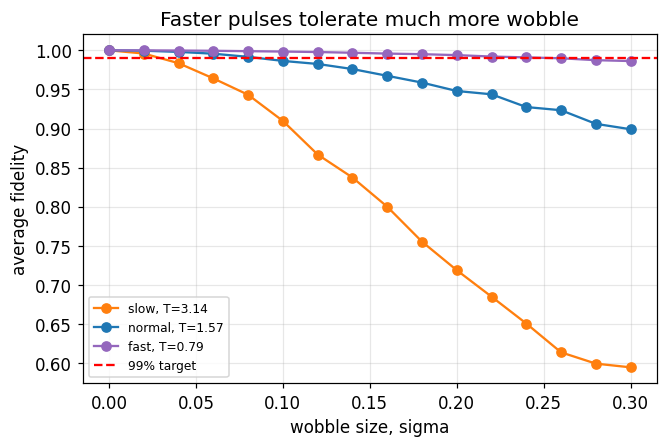

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(sigma_values, mean_fid_slow, "o-", color="tab:orange", label=f"slow, T={T_slow:.2f}")
ax.plot(sigma_values, mean_fid_nominal, "o-", color="tab:blue", label=f"normal, T={T_nominal:.2f}")
ax.plot(sigma_values, mean_fid_fast, "o-", color="tab:purple", label=f"fast, T={T_fast:.2f}")
ax.axhline(0.99, color="red", ls="--", label="99% target")
ax.set_xlabel("wobble size, sigma")
ax.set_ylabel("average fidelity")
ax.set_title("Faster pulses tolerate much more wobble")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


**The headline result:** going from the slow pulse to the fast pulse
(4 times shorter) raises the tolerable wobble size roughly **10-fold**
($\sigma_c \approx 0.030 \to 0.259$). That's a much bigger improvement than
you'd expect just from "4 times less time to go wrong" — the benefit of
speed is disproportionately large. Section 7 explains the maths behind why.


## 6. What does a "typical" run actually look like?

**What this section does:** instead of only looking at the *average*
fidelity, this section looks at the full spread of the 1000 individual
fidelity values at three wobble sizes — small, medium (near $\sigma_c$),
and large — to see *how* the gate fails, not just *how much*.


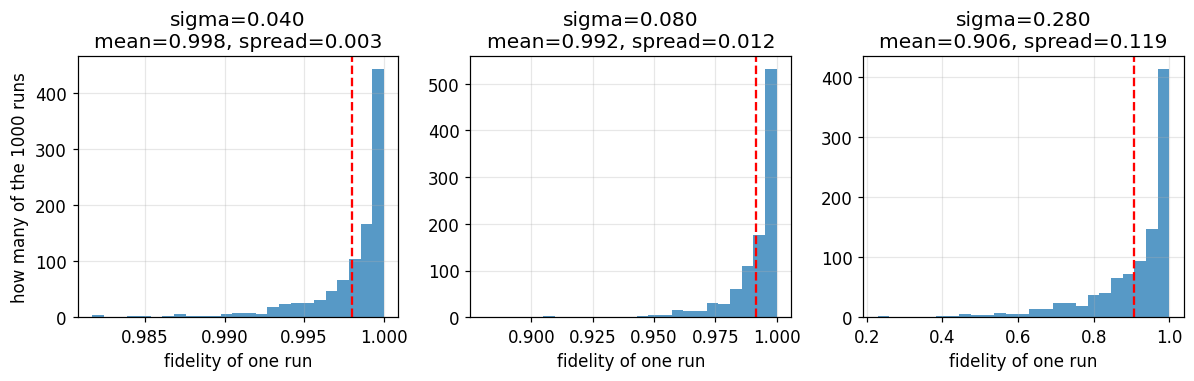

In [10]:
example_sigmas = [0.04, 0.08, 0.28]
sigma_indices = [np.argmin(np.abs(sigma_values - s)) for s in example_sigmas]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, idx in zip(axes, sigma_indices):
    fids = every_fid_nominal[idx]
    ax.hist(fids, bins=25, color="tab:blue", alpha=0.75)
    ax.axvline(fids.mean(), color="red", ls="--")
    ax.set_title(f"sigma={sigma_values[idx]:.3f}\nmean={fids.mean():.3f}, spread={fids.std():.3f}")
    ax.set_xlabel("fidelity of one run")
axes[0].set_ylabel("how many of the 1000 runs")
fig.tight_layout()
plt.show()


**What to say about this in the exam:** at low wobble, almost every run
lands in a tight cluster near perfect (1.0) — the gate is reliable. Near the
critical wobble size, the results spread out a lot and a "tail" of worse
runs starts to appear, even though the average is still fine. At high
wobble, most runs are now genuinely poor, with only a shrinking cluster of
"lucky" runs staying near 1.0.

This matters practically: a system that looks "mostly fine" on average can
already have a meaningful chance of a genuinely bad individual run. For
anything safety- or accuracy-critical, the worst-case tail matters more than
the average.


## 7. Why is the speed benefit so large? (the maths behind Section 5)

**What this section does:** checks a specific mathematical prediction for
*how much* faster pulses should help, and tests it against the three
$\sigma_c$ values found above.

The wobble is a random walk, and random walks have a property: the total
"randomness accumulated" over a stretch of time $T$ grows with $T^3$, not
just $T$ (this comes from how the variance of an *integrated* random walk
scales). Flipping that around, for the gate to keep the same quality, the
tolerable wobble size should scale like $T^{-3/2}$ — i.e.
$\sigma_c \times T^{1.5}$ should come out to roughly the same number no
matter which pulse speed we use, *if* this theory is right.


In [11]:
for name, dial, T, sig_c in [
    ("slow", dial_slow, T_slow, sigma_c_slow),
    ("normal", dial_nominal, T_nominal, sigma_c_nominal),
    ("fast", dial_fast, T_fast, sigma_c_fast),
]:
    print(f"{name:7s}: sigma_c * T^1.5 = {sig_c * T ** 1.5:.4f}")


slow   : sigma_c * T^1.5 = 0.1644
normal : sigma_c * T^1.5 = 0.1700
fast   : sigma_c * T^1.5 = 0.1787


The three values come out close to each other (about 0.17 each time,
across a 4-fold range of pulse length), which supports the $T^{-3/2}$
prediction. In plain terms: because the wobble is a random walk rather than
a steady drift, its damaging effect builds up much faster than linearly
with time, so cutting the pulse time even a little buys a disproportionately
large improvement in noise tolerance. This is also why there's no "sweet
spot" pulse speed in this model — under this particular kind of wobble,
faster is always better (real hardware has other limits not modelled here,
such as how much power a faster pulse needs).


## 8. Checking the simulation itself is trustworthy

**What this section does:** re-runs one wobble sweep point at several
different "wobble path resolutions" ($M$, how many small steps make up the
random walk) to check that the results above are genuine physics and not an
accident of how finely we happened to chop up the random path.


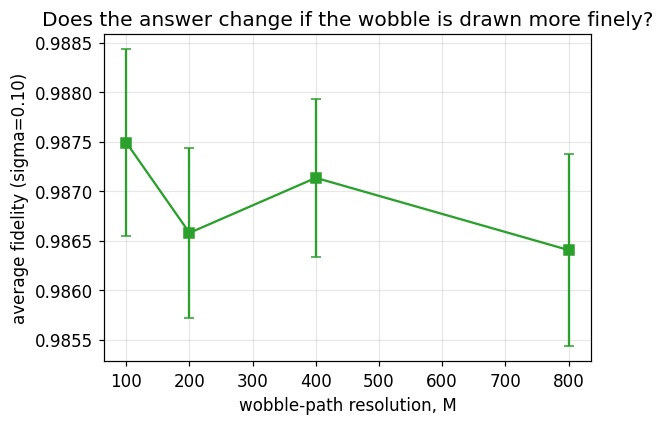

In [12]:
M_values = [100, 200, 400, 800]
conv_means, conv_stds = [], []
sigma_check = 0.10
runs_for_check = 400

for i, M in enumerate(M_values):
    rng_conv = np.random.default_rng(MASTER_SEED + 10 + i)
    fids = run_many_gates(dial_nominal, sigma_check, T_nominal, M, runs_for_check, rng_conv)
    conv_means.append(fids.mean())
    conv_stds.append(fids.std() / np.sqrt(runs_for_check))  # standard error of the mean

fig, ax = plt.subplots(figsize=(5.6, 4.0))
ax.errorbar(M_values, conv_means, yerr=conv_stds, fmt="s-", capsize=3, color="tab:green")
ax.set_xlabel("wobble-path resolution, M")
ax.set_ylabel("average fidelity (sigma=0.10)")
ax.set_title("Does the answer change if the wobble is drawn more finely?")
fig.tight_layout()
plt.show()


The average fidelity barely moves across an 8-fold change in $M$, and
the differences are well within the expected statistical noise (the error
bars). So $M=300$, used everywhere above, is fine enough that the results
reflect real physics rather than a coarse random-walk approximation.


## 9. Summary — the whole project in five lines

- A no-wobble run matches the exact textbook answer to about 1 part in a
  billion, so the simulation engine is trustworthy.
- At normal speed, average fidelity drops below the 99% target once the
  wobble size passes about $\sigma_c \approx 0.086$.
- A pulse 4 times shorter tolerates roughly **10 times** more wobble —
  speed helps far more than "linearly", because the wobble is a random
  walk and its damage builds up like $T^3$, giving $\sigma_c \propto T^{-3/2}$.
- The spread of outcomes, not just the average, gets much worse near and
  beyond the critical wobble size — a "mostly fine" average can hide a real
  chance of a bad individual run.
- The results don't change if the random wobble path is drawn more finely,
  so they reflect real physics, not a numerical artefact.


## 10. Likely oral exam questions — a quick prep sheet

- **"Why did you turn two complex numbers into four real numbers?"**
  Computer ODE solvers (like `solve_ivp`) work with real numbers, not
  complex ones, so splitting $a$ and $b$ into real and imaginary parts is
  the standard trick to make a complex-valued physics equation solvable
  numerically.

- **"Why is one simulation not enough — why 1000?"**
  A single wobble path is one random outcome among many possible ones. One
  run could get lucky or unlucky. Only the distribution over many
  independent repeats tells us how the gate performs *in general* — this
  is the core idea of a Monte Carlo experiment.

- **"How do you know your code is actually correct?"**
  By switching the wobble off and comparing to the exact pen-and-paper
  solution (Section 1's check), and by checking the result doesn't change
  when the wobble path is drawn more finely (Section 8).

- **"Why does a faster pulse tolerate so much more noise?"**
  Because the wobble is a random walk, not a steady drift, its accumulated
  effect grows with $T^3$, not $T$. Shorter pulses give the randomness far
  less time to build up, so the benefit of speed is much bigger than a
  naive "shorter time, proportionally less error" guess would suggest.

- **"What are the main limitations of this model?"**
  It only wobbles the drive frequency — no other noise sources, and no
  natural loss of coherence over time (decoherence) is included. The
  wobble itself is an unbounded random walk rather than a more realistic
  bounded/correlated noise process, and the critical-wobble numbers found
  here are specific to this noise model, not universal.

- **"What would you do next with more time?"**
  Try a different, more realistic noise model (one that doesn't wander off
  forever, and that has some time-correlation), and add a second physical
  effect such as decoherence, to see whether the same "speed helps a lot"
  conclusion survives.
